# Set 14 - NN2: Transfer Learning - nur den Kopf trainieren

**Ziel:** Einen echten vortrainierten Vision-Backbone nutzen, seine Gewichte und BatchNorm-Statistiken einfrieren und nur einen neuen linearen Kopf für zehn Ziffernklassen lernen.

Wir verwenden **MobileNetV3 Small mit ImageNet-Gewichten** aus torchvision. Der einmalige Download ist ungefähr 10 MB groß. Danach bleiben Gewichte und berechnete Features lokal. Alle Berechnungen laufen auf der CPU.

Die Ziffernbilder sind bewusst dieselben kleinen Daten wie zuvor. ImageNet enthält natürliche RGB-Bilder; 8×8-Graustufenziffern sind eine andere Domäne. Das Beispiel zeigt den Mechanismus, behauptet aber keinen automatischen Genauigkeitsvorteil gegenüber einem direkt trainierten CNN. Bezug zur PDF: Pretraining/Transfer Learning auf Seite 26.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn

kandidaten=[Path.cwd(),*Path.cwd().parents]
set_ordner=next((p for basis in kandidaten for p in (basis,basis/"set14-neuronale-netze-nn2")
                 if (p/"cv_tools.py").exists()),None)
if set_ordner is None:raise FileNotFoundError("Notebook innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:sys.path.insert(0,str(set_ordner))
from cv_tools import (cpu_setup,ziffern_split,loader,trainiere,auswerten,lernkurven,
                      bildgalerie,KleinesCNN,FrozenMobileNet,backbone_hash,
                      mobilenet_bilder,extrahiere_features)
device=cpu_setup()
print("PyTorch:",torch.__version__,"Gerät:",device,"CUDA-Build:",torch.version.cuda)
assert torch.version.cuda is None

PyTorch: 2.14.1+cpu Gerät: cpu CUDA-Build: None


In [2]:
bilder,labels,split=ziffern_split()
modell=FrozenMobileNet().to(device)
print("Backbone trainierbar:",sum(p.numel() for p in modell.backbone.parameters() if p.requires_grad))
print("Neuer Kopf trainierbar:",sum(p.numel() for p in modell.head.parameters() if p.requires_grad))
print("Kopf:",modell.head)
vorher_hash=backbone_hash(modell)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to \\ROBNEXUS\Home\Consulting\alfa\MachineLearning-Kurs\Code\set14-neuronale-netze-nn2\daten\torch_cache\checkpoints\mobilenet_v3_small-047dcff4.pth


Backbone trainierbar: 0
Neuer Kopf trainierbar: 5770
Kopf: Linear(in_features=576, out_features=10, bias=True)


## 1. Das Preprocessing gehört zu den Gewichten

Wir übernehmen `weights.transforms()`: RGB, Resize/Crop auf 224×224 und ImageNet-Normalisierung. Die Graustufenziffer wird in drei gleiche Farbkanäle umgewandelt. Das Vergrößern erzeugt keine neue echte Bildinformation.

Wir ersetzen nicht nur die Ausgabezahl des Originalmodells: Der ursprüngliche ImageNet-Klassifikationskopf wird entfernt. Der Backbone erzeugt 576 Merkmale; darauf sitzt unser neuer Kopf `Linear(576, 10)`.

Vorbereitetes Batch: torch.Size([2, 3, 224, 224])
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


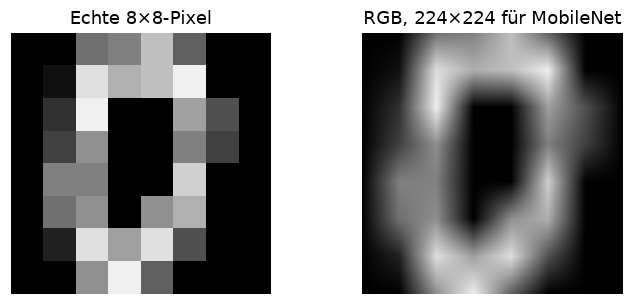

In [3]:
vorbereitet=mobilenet_bilder(bilder[split["train"]][:2],modell.weights)
print("Vorbereitetes Batch:",vorbereitet.shape)
print(modell.weights.transforms())
fig,axes=plt.subplots(1,2,figsize=(7,3))
axes[0].imshow(bilder[split["train"]][0,0],cmap="gray",vmin=0,vmax=1);axes[0].set_title("Echte 8×8-Pixel")
# Für eine lesbare Darstellung die Modellnormalisierung zurücknehmen.
mean=torch.tensor([0.485,0.456,0.406])[:,None,None]
std=torch.tensor([0.229,0.224,0.225])[:,None,None]
axes[1].imshow((vorbereitet[0]*std+mean).permute(1,2,0).clamp(0,1));axes[1].set_title("RGB, 224×224 für MobileNet")
for ax in axes:ax.axis("off")
plt.tight_layout();plt.show()

## 2. Einfrieren heißt mehr als keine Gradienten

`requires_grad=False` verhindert Gewichtsgradienten. Zusätzlich bleibt der Backbone in `eval()`; sonst könnten BatchNorm-Schichten ihre laufenden Statistiken ändern. Unsere Modellklasse hält den Backbone auch dann in eval, wenn der neue Kopf auf Training gestellt wird.

Wir extrahieren Features einmal ohne Gradienten und cachen sie. Weil Backbone und Eingabetransformation fest vortrainiert sind, wird hierbei nichts aus den neuen Ziffernlabels gelernt. Das darf für alle Splits geschehen. Die anschließende Merkmalsnormalisierung wird dagegen **nur auf Trainingsfeatures** gelernt.

In [4]:
modell.train()
assert not modell.backbone.training and modell.head.training
features=extrahiere_features(modell,bilder)
print("Feature-Tabelle:",features.shape)
train_features=features[split["train"]]
with torch.no_grad():
    modell.feature_mean.copy_(train_features.mean(0))
    modell.feature_std.copy_(train_features.std(0).clamp_min(1e-4))
standardisiert=(features-modell.feature_mean)/modell.feature_std
train_loader=loader(standardisiert[split["train"]],labels[split["train"]],shuffle=True)
val_loader=loader(standardisiert[split["val"]],labels[split["val"]])
test_loader=loader(standardisiert[split["test"]],labels[split["test"]])

Features berechnet und lokal gecacht: torch.Size([1797, 576])
Feature-Tabelle: torch.Size([1797, 576])


## 3. Nur ein kleiner Kopf lernt

Die Feature-Vektoren sind jetzt die Eingaben. Der Optimizer sieht ausschließlich `modell.head.parameters()`. Durch den Cache entfallen erneute Backbone-Durchläufe in jeder Epoche. Das ist echtes Feature-Extraction-Transfer-Learning, kein vollständiges Fine-Tuning.

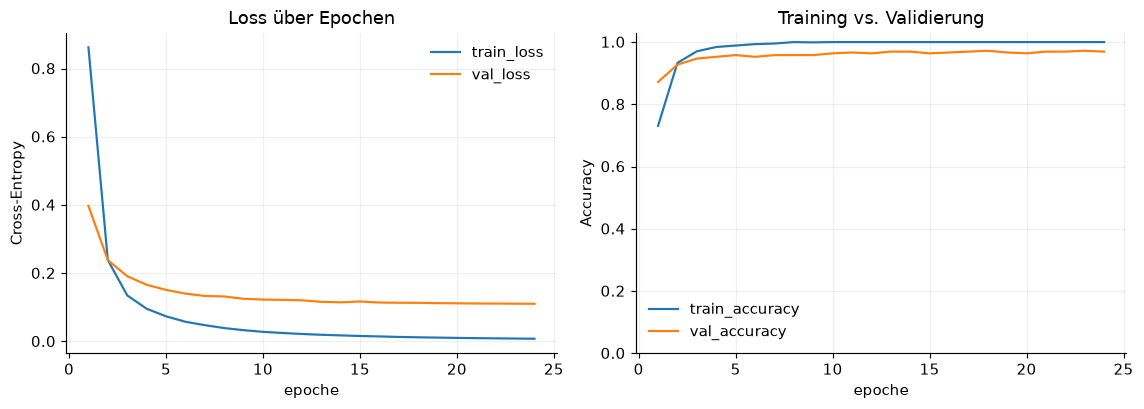

Backbone inklusive BatchNorm-Puffer unverändert: True


In [5]:
historie=trainiere(modell.head,train_loader,val_loader,epochen=24,lr=0.003)
lernkurven(historie)
assert backbone_hash(modell)==vorher_hash
assert all(not p.requires_grad and p.grad is None for p in modell.backbone.parameters())
print("Backbone inklusive BatchNorm-Puffer unverändert:",backbone_hash(modell)==vorher_hash)

## 4. Finaler Test des neuen Kopfes

Die Testfeatures werden mit Trainingsmittelwert und -standardabweichung transformiert. Das Modell hat die Testlabels nicht zum Lernen gesehen. Die Auswahl der Epoche erfolgt nur über die Validierungs-Loss.

Transfer-Learning-Test: {'loss': 0.09037295579910279, 'accuracy': 0.9750000238418579}


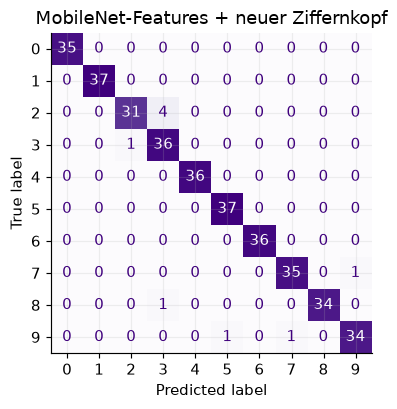

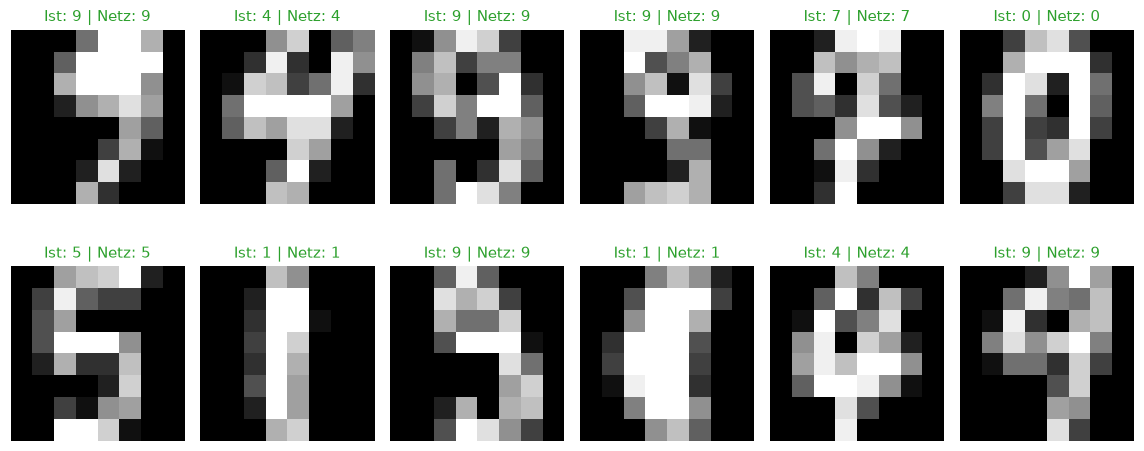

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
metriken,probs,y_test=auswerten(modell.head,test_loader)
print("Transfer-Learning-Test:",metriken)
ConfusionMatrixDisplay.from_predictions(y_test.numpy(),probs.argmax(1).numpy(),cmap="Purples",colorbar=False)
plt.title("MobileNet-Features + neuer Ziffernkopf");plt.tight_layout();plt.show()
bildgalerie(bilder[split["test"]],y_test,probs)

## 5. Das zusammengesetzte Modell weiterhin auf Bildern nutzen

Beim vollständigen Modell laufen RGB-Bild → eingefrorener Backbone → Trainingsnormalisierung → neuer Kopf. Die Vorhersage muss der entsprechenden Cache-Vorhersage entsprechen. Wir prüfen dies rechnerisch an drei Testbildern.

In [7]:
modell.eval()
probe_bilder=bilder[split["test"]][:3]
probe=mobilenet_bilder(probe_bilder,modell.weights)
with torch.inference_mode():voll=modell(probe).softmax(1)
assert torch.allclose(voll,probs[:3],atol=1e-4,rtol=1e-4)
display(pd.DataFrame(voll.numpy(),columns=range(10)).round(3))
print("Bildmodell und Feature-Cache stimmen überein.")

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.000,0.002,0.000,0.001,0.0,0.000,0.000,0.997
1,0.0,0.0,0.004,0.000,0.827,0.026,0.0,0.143,0.000,0.000
2,0.0,0.0,0.000,0.013,0.000,0.003,0.0,0.000,0.002,0.982


Bildmodell und Feature-Cache stimmen überein.


## Kleine Fragen
1. Welche Parameter lernt der neue Kopf, welche bleiben eingefroren?
2. Warum reicht `requires_grad=False` bei BatchNorm allein nicht aus?
3. Wann muss ein Feature-Cache neu erzeugt werden?
4. Weshalb muss Transfer Learning hier nicht besser als das kleine CNN sein?

Referenzen: [MobileNetV3 Small](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v3_small.html), [offizielles Transfer-Learning-Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).